# Imports

In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

# Условия

Вычислить определённый интеграл $\int \limits_a^b f(x) dx$, заменяя подынтегральную функцию интерполирующим её дискретным кубическим сплайном.

Граничные условия 2-го типа.

Пример 11.

Численные эксперименты провести для функций, указанных в таблице, по параметру  $\epsilon$  дискретного сплайна. 

$S''(a)=f''_0,\quad S''(b)=f''_N$

$$
\int \limits_0^1 \dfrac{\arctg(x)}{x} dx
$$

In [3]:
A = [0, 1]

In [4]:
class Fun:
    def __init__(self, func, dfunc, ddfunc, name: str):
        self.name = name

        self.f = func
        self.df = dfunc
        self.ddf = ddfunc

    def __call__(self, x: float | list[float], step: int = 0) -> float | list[float]:
        """Вычисление значения функции в точке

        Args:
            x (float | list[float]): x
            step (int, optional): Степень производной. Defaults to 0.

        Returns:
            float: Значение функции в точке
        """
        if step == 0:
            return self.f(x)
        elif step == 1:
            return self.df(x)
        elif step == 2:
            return self.ddf(x)


f = Fun(
    func=lambda x: (np.arctan(x) / x) if x != 0 else 1,
    dfunc=lambda x: (1 / (x**3 + x) - (np.arctan(x)) / (x**2)),
    ddfunc=lambda x: (
        (2 * np.arctan(x)) / (x**3) - (2 * (2 * x**2 + 1)) / (x**6 + 2 * x**4 + x**2)
        if x != 0
        else (-2 / 3 if x != 1 else (np.pi - 3) / 2)
    ),
    name="$\\dfrac{\\arctan(x)}{x}$",
)

In [5]:
def gen_points(
    start: float,
    stop: float,
    N: int,
    is_rand: bool = False,
) -> tuple[np.ndarray, float]:
    x = np.linspace(start, stop, N)
    h = x[1] - x[0]
    if is_rand:
        for idx in range(1, len(x) - 1):
            x[idx] += np.random.random() * 2 * h / 3 - h / 3
    return x, h

In [6]:
def calc(eps: float, N: int, func: Fun, start: float, stop: float):
    x, h = gen_points(start, stop, N + 1)
    ddf_i_val, ddf_e_val = func(x[0], 2), func(x[-1], 2)

    y: list[float] = [func(item) for item in x]  # type: ignore

    mu = h / (h + h)
    lam = 1 - mu

    Am = np.zeros((N + 1, N + 1))
    bm = np.zeros(N + 1)

    Am[0, 0] = 1
    bm[0] = ddf_i_val

    for i in range(1, N):
        Am[i, i - 1] = mu * (1 - (eps**2) / (h**2))
        Am[i, i] = 2 + (eps**2) / (h**2)
        Am[i, i + 1] = lam * (1 - (eps**2) / (h**2))
        bm[i] = (6 / (h + h)) * (
            ((func(x[i + 1]) - func(x[i])) / h)  # type: ignore
            - ((func(x[i]) - func(x[i + 1])) / h)  # type: ignore
        )

    Am[N, N] = 1
    bm[N] = ddf_e_val

    m = np.linalg.solve(Am, bm)

    return x, y, m, h

# Доп функции

In [7]:
def spline_eval(x_eval, x_nodes, y_nodes, m, h):
    """
    Вычисление значений сплайна в точках x_eval
    """
    n = len(x_nodes)
    y_eval = np.zeros_like(x_eval)

    for j, x_val in enumerate(x_eval):
        # Находим индекс отрезка, содержащего x_val
        i = np.searchsorted(x_nodes, x_val) - 1
        if i < 0:
            i = 0
        elif i >= n - 1:
            i = n - 2

        # Вычисляем параметр t для текущего отрезка
        t = (x_val - x_nodes[i]) / h

        # Базисные функции Эрмита
        H1 = 2 * t**3 - 3 * t**2 + 1
        H2 = -2 * t**3 + 3 * t**2
        H3 = t**3 - 2 * t**2 + t
        H4 = t**3 - t**2

        # Вычисляем значение сплайна
        y_eval[j] = (
            y_nodes[i] * H1 + y_nodes[i + 1] * H2 + h * m[i] * H3 + h * m[i + 1] * H4
        )

    return y_eval

In [8]:
def calculate_error(x_eval, y_true, y_approx):
    absolute_error = np.abs(y_true - y_approx)
    max_error = np.max(absolute_error)
    rmse = np.sqrt(np.mean(absolute_error**2))

    return max_error, rmse, absolute_error

# Код

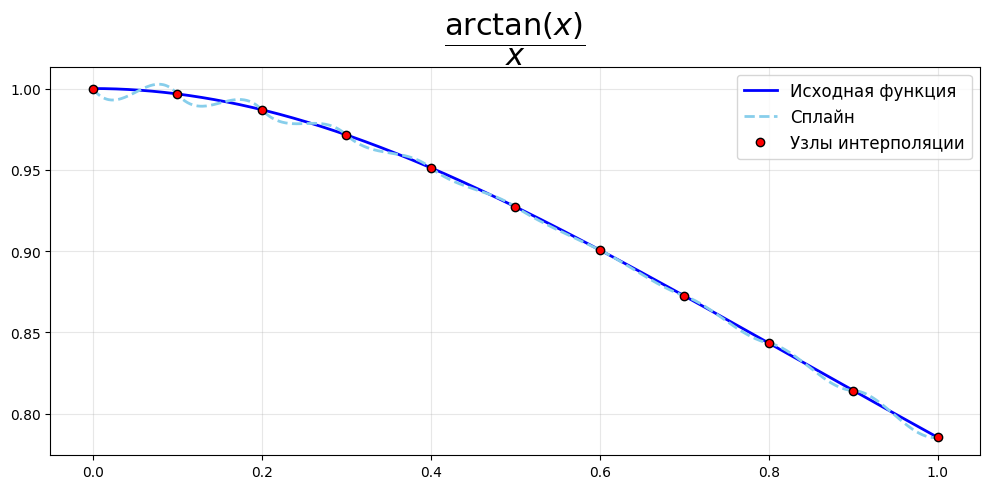

In [9]:
eps = 10
N = 10

plt.figure(figsize=(10, 5))

x, y, m, h = calc(eps, N, f, A[0], A[1])

# Генерируем плотную сетку для гладкого отображения
x_dense = np.linspace(A[0], A[1], 1000)

# Вычисляем значения исходной функции и сплайна на плотной сетке
y_true = [f(x_d) for x_d in x_dense]
y_spline = spline_eval(x_dense, x, y, m, h)

# Строим графики
plt.title(f"{f.name}", fontsize=22)
plt.plot(x_dense, y_true, "blue", label="Исходная функция", linewidth=2)
plt.plot(
    x_dense, y_spline, color="skyblue", linestyle="--", label="Сплайн", linewidth=2
)
plt.plot(
    x, y, "ro", label="Узлы интерполяции", markersize=6, markeredgecolor="black"
)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# При нефиксированном $N$

In [10]:
def experiment_vary_N(eps, N_values, func, start, stop):
    max_errors = []
    rmse_errors = []
    
    for N in N_values:
        # Строим сплайн
        x, y, m, h = calc(eps, N, func, A[0], A[1])
        
        # Генерируем плотную сетку для оценки ошибки
        x_dense = np.linspace(start, stop, 1000)
        y_true = [func(x_d) for x_d in x_dense]
        y_spline = spline_eval(x_dense, x, y, m, h)
        
        # Вычисляем ошибки
        max_error, rmse, _ = calculate_error(x_dense, y_true, y_spline)
        max_errors.append(max_error)
        rmse_errors.append(rmse)
    
    return max_errors, rmse_errors

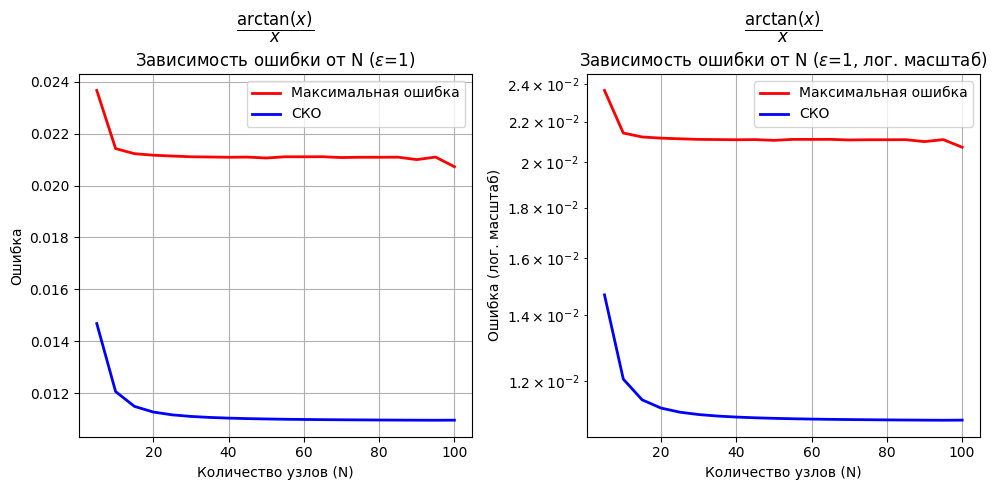

In [11]:
eps = 1
N_values = np.arange(5, 100 + 1, 5)

plt.figure(figsize=(10, 5))
max_errors, rmse_errors = experiment_vary_N(
    eps, N_values, f, A[0], A[1]
)

# Графики ошибок для эксперимента 1
plt.subplot(1, 2, 1)
plt.plot(N_values, max_errors, "r-", label="Максимальная ошибка", linewidth=2)
plt.plot(N_values, rmse_errors, "b-", label="СКО", linewidth=2)
plt.xlabel("Количество узлов (N)")
plt.ylabel("Ошибка")
plt.title(f"{f.name}\nЗависимость ошибки от N ($\\epsilon$={eps})")
plt.legend()
plt.grid(True)

# Логарифмический масштаб для лучшей визуализации
plt.subplot(1, 2, 2)
plt.semilogy(N_values, max_errors, "r-", label="Максимальная ошибка", linewidth=2)
plt.semilogy(N_values, rmse_errors, "b-", label="СКО", linewidth=2)
plt.xlabel("Количество узлов (N)")
plt.ylabel("Ошибка (лог. масштаб)")
plt.title(f"{f.name}\nЗависимость ошибки от N ($\\epsilon$={eps}, лог. масштаб)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# При нефиксированном $eps$

In [12]:
def experiment_vary_eps(eps_values, N, func, start, stop):
    max_errors = []
    rmse_errors = []

    for eps in eps_values:
        # Строим сплайн
        x, y, m, h = calc(eps, N, func, A[0], A[1])

        # Генерируем плотную сетку для оценки ошибки
        x_dense = np.linspace(start, stop, 1000)
        y_true = [func(x_d) for x_d in x_dense]
        y_spline = spline_eval(x_dense, x, y, m, h)

        # Вычисляем ошибки
        max_error, rmse, _ = calculate_error(x_dense, y_true, y_spline)
        max_errors.append(max_error)
        rmse_errors.append(rmse)

    return max_errors, rmse_errors

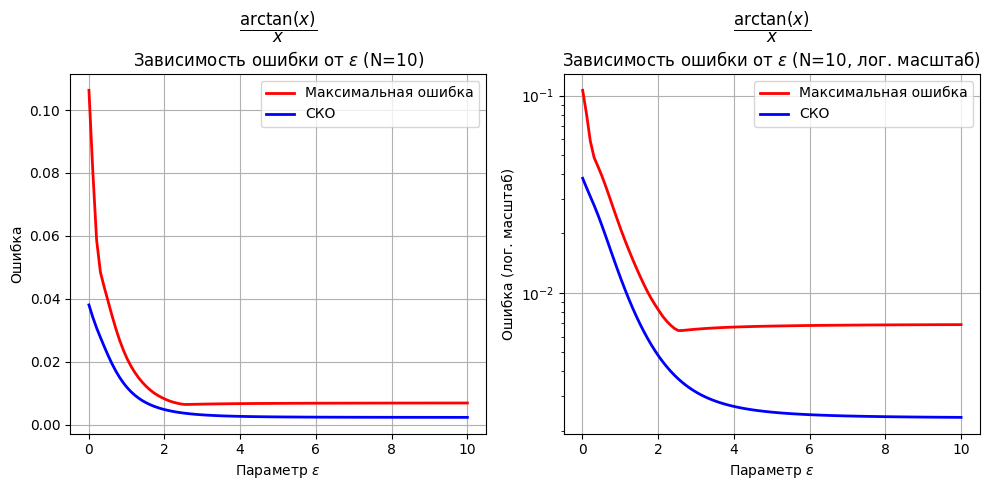

In [13]:
eps_values = np.linspace(0.01, 10, 100)  # a от 1 до 10

plt.figure(figsize=(10, 5))


max_errors, rmse_errors = experiment_vary_eps(eps_values, N, f, A[0], A[1])

# Графики ошибок для эксперимента 2
plt.subplot(1, 2, 1)
plt.plot(eps_values, max_errors, "r-", label="Максимальная ошибка", linewidth=2)
plt.plot(eps_values, rmse_errors, "b-", label="СКО", linewidth=2)
plt.xlabel("Параметр $\\epsilon$")
plt.ylabel("Ошибка")
plt.title(f"{f.name}\nЗависимость ошибки от $\\epsilon$ (N={N})")
plt.legend()
plt.grid(True)

# Логарифмический масштаб для лучшей визуализации
plt.subplot(1, 2, 2)
plt.semilogy(eps_values, max_errors, "r-", label="Максимальная ошибка", linewidth=2)
plt.semilogy(eps_values, rmse_errors, "b-", label="СКО", linewidth=2)
plt.xlabel("Параметр $\\epsilon$")
plt.ylabel("Ошибка (лог. масштаб)")
plt.title(f"{f.name}\nЗависимость ошибки от $\\epsilon$ (N={N}, лог. масштаб)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()